# **AIN 214 - PA2 - FALL 2024**

**Student Number** : 2210765048

**Name Surname**   : Büşra Şerbetci


BELOW MD CELLS CONTAIN THE QUESTIONS YOU ARE ASKED TO IMPLEMENT WITHIN THE CONTEXT OF THIS HW. PLEASE FILL IN THE CELLS FOR THE ANSWERS RIGHT BELOW THE MD CELL OF THE QUESTION. YOU CAN ADD AS MANY CELLS AS YOU WANT, BE IT CODE OR MD, SO LONG AS YOU PROVIDE UNDERSTANDABLE AND TRACEABLE REPORTING. PLEASE ADD COMMENTS ON YOUR CODES. ALSO, FILL IN MD CELLS WHERE YOU ARE ASKED TO COMMENT ON YOUR RESULTS OR EXPLAIN YOUR REASONING. ALSO, PLEASE DO NOT HESITATE TO USE THEM FOR YOUR OWN REPORTING PURPOSES. PLEASE KEEP IN MIND THAT, REPORTING IS A KEY STEP IN DATA SCIENCE.

**Deadline: 08.11.2024 (23:59:59)**

**Submission:** Submit your Jupyter Notebooks via https://submit.cs.hacettepe.edu.tr/

<font color='red'> **!!! PLEASE RUN YOUR CODE.   THE OUTPUT OF YOUR CODE MUST BE VISIBLE. DO NOT DELETE OR HIDE THE OUTPUT.**</font>

# **Necessary Imports**

In [1]:
# Import required libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **PART- 1**

**Set of Questions on Healthcare Management System (60 Pts)**



For this part, you will use a dataset related to a Healthcare Management System. The dataset includes information about patients, doctors, medical procedures, and healthcare operations.



* **Patients**: There are many patients within the healthcare system. The system holds details that help identify the patient, such as the name and email of the patient receiving medical care.

* **Doctors**: Profiles of healthcare professionals within the facility are stored. Each record provides information about the doctor's identity, including name, specialty and contact information, which is crucial for directing patients to appropriate medical services and ensuring effective communication.

* **Appointments**: Tracks all scheduled visits between patients and doctors and serves as a vital component of the health management system. It keeps records of the appointment date and time, the patient and doctor involved and plays a critical role in managing patient flow and optimizing the use of healthcare resources.

* **Medical Procedures**: It is necessary to catalog the various treatments and diagnostic services offered by the healthcare facility. It is essential to provide clarity on the types of medical interventions available, which aids both clinical and financial planning.

* **Billing**: It is important to record all financial transactions related to patient appointments and procedures. It keeps track of the items billed to patients along with their respective amounts, which is crucial for the financial health of the health facility, allowing for accurate monitoring of income and outstanding balances.


This dataset will be used to design a relational database for managing healthcare operations, which includes data about patients, doctors, appointments, and more. Your task is to build an efficient database schema and write SQL queries.

---


**Dataset Path:** "Data/Appointments_procedures.csv, Patient_billing.csv , Doctors.csv"
  
---

**Note:** Use sqite3 python package for DB

---

# **Q1**. Design your schema as tables. Draw the necessary tables with the appropriate attributes. State the primary keys, foreign keys (and their references). Create the tables in your schema in the database. (10 Points)

There is no single soluion here, come up with your own design.

***Patient's Table***:
| Column   | Type  | Key      | Description                              |
|----------|-------|----------|------------------------------------------|
|PatientID |INTEGER| PK       | Unique identifier for each patient       |
|firstname |TEXT   |          | First name of the patient                |
|lastname  |TEXT   |          | Last name of the patient                 |
|email     |TEXT   |          | Contact email for the patient            |


***Doctors Table***:
| Column        | Type  | Key      | Description                              |
|---------------|-------|----------|------------------------------------------|
|DoctorID       |INTEGER| PK       | Unique identifier for each doctor        |
|DoctorName     |TEXT   |          | Name of the doctor                       |
|Specialization |TEXT   |          | Doctor's area of specilization           |
|DoctorContact  |TEXT   |          | Contact details for the doctor           |


***Appointments Table***:
| Column           | Type   | Key      | Description                              |
|------------------|--------|----------|------------------------------------------|
|AppointmentID     |INTEGER | PK       | Unique identifier for each appointment   |
|Date & Time       |DATETIME|          | Date and time of the appointment         |
|PatientID         |INTEGER | FK       | References patient_id in Patients table  |
|DoctorID          |INTEGER | FK       | References doctor_id in Doctors table    |
| FOREIGN KEY (PatientID) REFERENCES Patients(PatientID)     |    |     |         |
| FOREIGN KEY (DoctorID) REFERENCES Doctors(DoctorID)        |    |     |         |


***Procedures Table***:
| Column       | Type  | Key      | Description                              |
|--------------|-------|----------|------------------------------------------|
|ProcedureID   |INTEGER| PK       | Unique identifier for each procedure     |
|ProcedureName |TEXT   |          | Name of the medical procedure            |
|description   |TEXT   |          | Description of the procedure             |
|cost          |REAL   |          | Cost associated with the procedure       |


***Billing Table***:
| Column         | Type   | Key      | Description                                    |
|----------------|--------|----------|------------------------------------------------|
|InvoiceID       |INTEGER | PK       | Unique identifier for each billing entry       |
|AppointmentID   |INTEGER | FK       | References appointment_id in Appointments table|
|ProcedureID     |INTEGER | FK       | References procedure_id in Procedures table    |
|Amount          |REAL    |          | Billed amount for the procedure                |
| FOREIGN KEY (AppointmentID) REFERENCES Appointments(AppointmentID)    |   |   |     |
| FOREIGN KEY (ProcedureID) REFERENCES Procedures(ProcedureID)          |   |   |     |




In [2]:
#Create a connection to SQLite database
conn = sqlite3.connect('healthcare.db')

#Create tables based on the schema above
patients_table = '''
CREATE TABLE IF NOT EXISTS Patients (
    PatientID INTEGER PRIMARY KEY,
    firstname TEXT,
    lastname TEXT,
    email TEXT
)
'''

doctors_table = '''
CREATE TABLE IF NOT EXISTS Doctors (
    DoctorID INTEGER PRIMARY KEY,
    DoctorName TEXT,
    Specialization TEXT,
    DoctorContact TEXT
)
'''

appointments_table = '''
CREATE TABLE IF NOT EXISTS Appointments (
    AppointmentID INTEGER PRIMARY KEY,
    `Date & Time` DATETIME,
    PatientID INTEGER,
    DoctorID INTEGER,
    FOREIGN KEY (PatientID) REFERENCES Patients(PatientID),
    FOREIGN KEY (DoctorID) REFERENCES Doctors(DoctorID)
)
'''

procedures_table = '''
CREATE TABLE IF NOT EXISTS Procedures (
    ProcedureID INTEGER PRIMARY KEY,
    ProcedureName TEXT,
    description TEXT,
    cost REAL
)
'''

billing_table = '''
CREATE TABLE IF NOT EXISTS Billing (
    InvoiceID INTEGER PRIMARY KEY,
    AppointmentID INTEGER,
    ProcedureID INTEGER,
    Amount REAL,
    FOREIGN KEY (AppointmentID) REFERENCES Appointments(AppointmentID),
    FOREIGN KEY (ProcedureID) REFERENCES Procedures(ProcedureID)
)
'''

#Execute the CREATE TABLE queries
conn.execute(patients_table)
conn.execute(doctors_table)
conn.execute(appointments_table)
conn.execute(procedures_table)
conn.execute(billing_table)

#Load CSV data into pandas DataFrames
patients_df = pd.read_csv("Data/Patient_billing.csv")
doctors_df = pd.read_csv("Data/Doctors.csv")
appointments_df = pd.read_csv("Data/Appointments_procedures.csv")
procedures_df = pd.read_csv("Data/Appointments_procedures.csv")
billing_df = pd.read_csv("Data/Patient_billing.csv")

#Insert the DataFrame data into the SQLite tables
patients_df.to_sql('Patients', conn, if_exists='replace', index=False)
doctors_df.to_sql('Doctors', conn, if_exists='replace', index=False)
appointments_df.to_sql('Appointments', conn, if_exists='replace', index=False)
procedures_df.to_sql('Procedures', conn, if_exists='replace', index=False)
billing_df.to_sql('Billing', conn, if_exists='replace', index=False)

#Commit the transaction
conn.commit()
cursor = conn.cursor()

# **Q2**.  Write a SQL query that retrieves the top 5 doctors based on the total number of appointments they have conducted. The results should include each doctor's doctor_id, doctor_name, and the corresponding total_appointments they have handled.(10 Points)

In [3]:
cursor.execute('''
    SELECT 
        D.DoctorID, 
        D.DoctorName AS doctor_name, 
        COUNT(A.AppointmentID) AS total_appointments
    FROM 
        Doctors D
    JOIN 
        Appointments A ON D.DoctorID = A.DoctorID
    GROUP BY 
        D.DoctorID
    ORDER BY 
        total_appointments DESC
    LIMIT 5;
''')

print("Top 5 Doctors by Appointment Count:")
for row in cursor.fetchall():
    print(row)


Top 5 Doctors by Appointment Count:
(548, 'Karlee', 6)
(925, 'Hyacinthe', 5)
(637, 'Lorenza', 5)
(527, 'Cristabel', 5)
(417, 'Molli', 5)


# **Q3**.  Calculates the total billing amount for each patient. The output should present each patient's patient_id, first_name, last_name, and the total_billed_amount. List the amount of the bill in descending order.(10 Points)

In [4]:
cursor.execute('''
    SELECT 
        Pa.PatientID,
        Pa.firstname,
        Pa.lastname,
        SUM(B.Amount) AS total_billed_amount
    FROM 
        Patients Pa
    JOIN 
        Billing B ON Pa.PatientID = B.PatientID
    GROUP BY 
        Pa.PatientID
    ORDER BY 
        total_billed_amount DESC;
''')

print("Total Billing Amount for Each Patient (Descending Order):")
for row in cursor.fetchall():
    print(row)


Total Billing Amount for Each Patient (Descending Order):
(733, 'Lesly', 'Arquit', 24210894)
(779, 'Candi', 'Shaver', 16418215)
(368, 'Stephanie', 'Agle', 13746812)
(373, 'Asia', 'Bendick', 11408355)
(240, 'Margette', 'Belldas', 11200012)
(448, 'Wendi', 'Gilmour', 10102935)
(242, 'Frieda', 'Bonilla', 9144000)
(546, 'Aimil', 'Suzetta', 8695756)
(879, 'Mildrid', 'Bakerman', 6857760)
(804, 'Madelle', 'Camden', 6657510)
(566, 'Rebeca', 'Winnick', 6641493)
(929, 'Sonni', 'Regan', 6564260)
(744, 'Averyl', 'Hutchison', 6451695)
(730, 'Agnese', 'Gherardo', 6258788)
(291, 'Roz', 'Oster', 6175020)
(514, 'Kirbee', 'Tarrant', 6004470)
(415, 'Doralynne', 'Harl', 5872998)
(174, 'Cam', 'Cordi', 5796177)
(961, 'Ruthe', 'Garbe', 5668260)
(930, 'Bernardine', 'Bates', 5639634)
(182, 'Annice', 'Randene', 5523873)
(353, 'Raina', 'Fabiola', 5515809)
(562, 'Sam', 'Florina', 5477355)
(261, 'Annecorinne', 'Papageno', 5458599)
(198, 'Sue', 'Guildroy', 5391543)
(409, 'Netty', 'Moseley', 5370324)
(603, 'Dolli', '

# **Q4**. Write a SQL query to find the most common medical procedures for every doctor. The result should include the doctor_id, doctor_name, procedure_name, and the count of how many times each procedure has been performed (procedure_count). (10 Points)

In [5]:
cursor.execute('''
SELECT 
    D.DoctorID,
    D.DoctorName,
    Pr.ProcedureName,
    COUNT(A.AppointmentID) AS procedure_count
FROM 
    Doctors D
JOIN 
    Appointments A ON D.DoctorID = A.DoctorID
JOIN 
    Procedures Pr ON A.ProcedureID = Pr.ProcedureID
GROUP BY 
    D.DoctorID, D.DoctorName, Pr.ProcedureName
ORDER BY 
    procedure_count DESC;
''')

results = cursor.fetchall()
print("Most Common Medical Procedures for Each Doctor:")
for row in results:
    print(row)

Most Common Medical Procedures for Each Doctor:
(417, 'Molli', 'Liver biopsy', 2)
(439, 'Noelle', 'X-rays, CT scans, MRI scans', 2)
(637, 'Lorenza', 'Interventional radiology procedures', 2)
(688, 'Constance', 'Surgical oncology', 2)
(925, 'Hyacinthe', 'General health check-ups', 2)
(929, 'Aryn', 'Well-child check-ups', 2)
(101, 'Mireielle', 'General surgery', 1)
(117, 'Karena', 'Anesthetic care during childbirth', 1)
(117, 'Karena', 'Angioplasty and stent placement', 1)
(117, 'Karena', 'Orthopedic surgery', 1)
(119, 'Flory', 'Pediatric surgery', 1)
(119, 'Flory', 'Symptom management for end-of-life care', 1)
(120, 'Lilith', 'Intensive care management', 1)
(129, 'Aurelie', 'Hemodynamic monitoring', 1)
(139, 'Aurelie', 'Allergy testing', 1)
(147, 'Shaylyn', 'Intensive care management', 1)
(147, 'Shaylyn', 'Kidney transplant', 1)
(151, 'Karly', 'Emergency surgical procedures', 1)
(151, 'Karly', 'Rhinoplasty', 1)
(154, 'Leanna', 'General anesthesia for surgeries', 1)
(155, 'Alleen', 'Reti

# **Q5**. Calculate the total revenue generated by each doctor from the procedures they have performed. The output should display the doctor_id, first_name and the total revenue (total_revenue) attributed to each doctor. (10 Points)

In [6]:
cursor.execute('''
SELECT 
    D.DoctorID,
    D.DoctorName,
    SUM(B.Amount) AS total_revenue
FROM 
    Doctors D
JOIN 
    Appointments A ON D.DoctorID = A.DoctorID
JOIN 
    Billing B ON A.PatientID = B.PatientID
GROUP BY 
    D.DoctorID, D.DoctorName
ORDER BY 
    total_revenue DESC;
''')

# Fetch and display the results
results = cursor.fetchall()
print("Total Revenue Generated by Each Doctor:")
for row in results:
    print(row)


Total Revenue Generated by Each Doctor:
(452, 'Minne', 7029997)
(189, 'Max', 6567286)
(617, 'Charissa', 5473767)
(975, 'Hettie', 4347878)
(558, 'Adriana', 3759756)
(237, 'Suzette', 3580216)
(243, 'Edith', 3436703)
(407, 'Bill', 3436703)
(801, 'Brooks', 3436703)
(637, 'Lorenza', 3183401)
(197, 'Ofilia', 3172966)
(943, 'Doro', 2875010)
(485, 'Tera', 2764512)
(486, 'Janis', 2533050)
(224, 'Dorene', 2479084)
(430, 'Eolanda', 2389798)
(548, 'Karlee', 2291637)
(129, 'Aurelie', 2286000)
(800, 'Hermione', 2273242)
(574, 'Ronna', 2206483)
(644, 'Corina', 2198910)
(532, 'Mureil', 1991556)
(679, 'Debee', 1987975)
(300, 'Roxane', 1889420)
(692, 'Nariko', 1889420)
(925, 'Hyacinthe', 1833260)
(667, 'Gloria', 1811415)
(877, 'Vevay', 1791430)
(929, 'Aryn', 1752721)
(947, 'Allis', 1657795)
(691, 'Andeee', 1650128)
(744, 'Lolita', 1632068)
(417, 'Molli', 1539372)
(768, 'Giustina', 1531215)
(931, 'Micheline', 1496295)
(183, 'Shauna', 1485334)
(344, 'Aurore', 1457998)
(443, 'Renie', 1354711)
(792, 'Leanna

# **Q6.** Identify patients who have had multiple appointments. The query should return the patient_id, first_name, last_name, and appointment_count. List the appointment_count in descending order. (10 Points)

In [7]:
cursor.execute("""
SELECT
    Pa.PatientID,
    Pa.firstname,
    Pa.lastname,
    COUNT(A.AppointmentID) as appointment_count
FROM
    Patients Pa
JOIN
   Appointments A ON Pa.PatientID = A.PatientID
GROUP BY 
    Pa.PatientID
HAVING 
    COUNT(A.AppointmentID) > 1
ORDER BY 
    appointment_count DESC; 
""")

print("Patients with Multiple Appointments:")
for row in cursor.fetchall():
    print(row)

conn.close()

Patients with Multiple Appointments:
(368, 'Stephanie', 'Agle', 20)
(779, 'Candi', 'Shaver', 10)
(546, 'Aimil', 'Suzetta', 8)
(381, 'Chickie', 'Hazlett', 8)
(242, 'Frieda', 'Bonilla', 8)
(961, 'Ruthe', 'Garbe', 6)
(940, 'Karolina', 'Roche', 6)
(930, 'Bernardine', 'Bates', 6)
(870, 'Carolina', 'Carbo', 6)
(766, 'Mellicent', 'Zaslow', 6)
(514, 'Kirbee', 'Tarrant', 6)
(411, 'Gaylene', 'Robertson', 6)
(409, 'Netty', 'Moseley', 6)
(696, 'Grier', 'Noam', 5)
(613, 'Zia', 'Wildermuth', 5)
(469, 'Ashlee', 'Annabella', 5)
(994, 'Gui', 'Turne', 4)
(979, 'Winifred', 'Tice', 4)
(977, 'Carree', 'Bach', 4)
(817, 'Trixi', 'Skurnik', 4)
(717, 'Tybie', 'Latini', 4)
(694, 'Paola', 'Swigart', 4)
(531, 'Brana', 'Redmond', 4)
(466, 'Myrtice', 'Oriana', 4)
(249, 'Nicoli', 'Doig', 4)
(190, 'Amara', 'Sawtelle', 4)
(149, 'Drucie', 'Nedrud', 4)
(131, 'Jaclyn', 'Euridice', 4)
(934, 'Sam', 'Cookie', 3)
(854, 'Berget', 'Hirsch', 3)
(802, 'Barbi', 'Lindemann', 3)
(634, 'Linzy', 'Tamar', 3)
(627, 'Kelly', 'Stoller', 

# **PART- 2**

**Set of Questions : DATA ANALYSIS WITH VISUALIZATION TOOLS** **(40 Pts)**

Answer the following questions, using visualization tools, and comment on your work.

---

**Dataset Path**: "Data/Suicides.csv"

---



In [8]:
suicide_df = pd.read_csv("Data/Suicides.csv")

# **Q1.** Create a pivot table showing the average suicide rate by country and year.  Which countries have the highest and lowest average suicide rates over the years? Analyze the data using this graph.(8 Points)

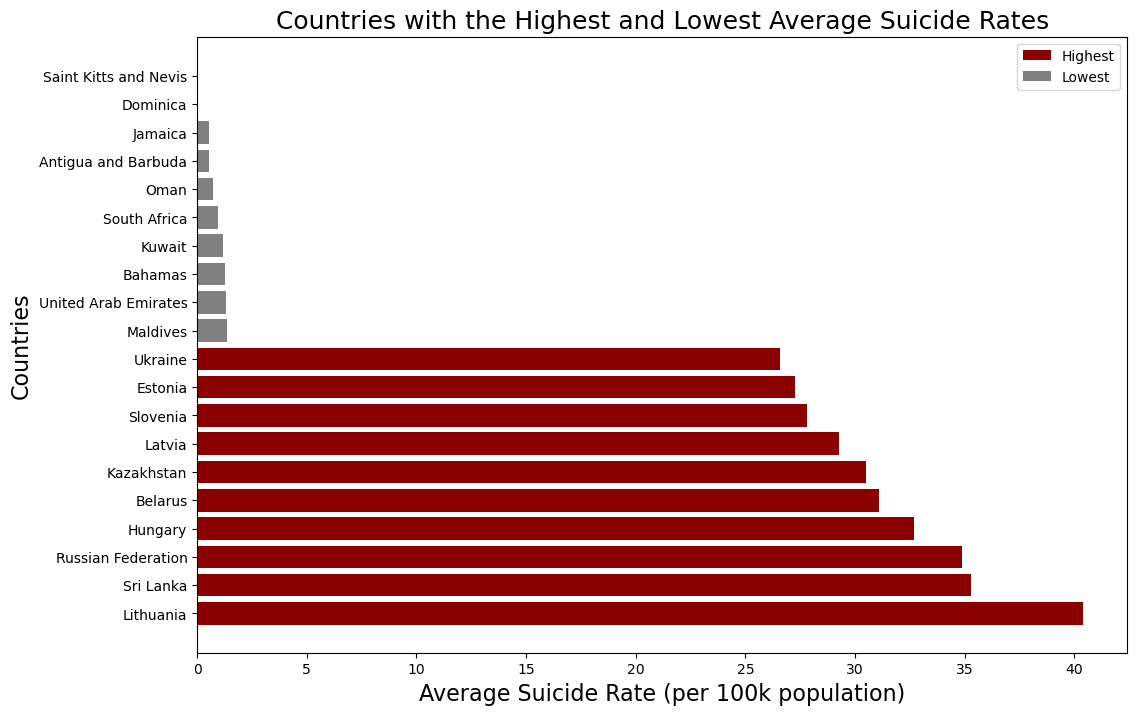

In [9]:
#Convert 'suicides/100k pop' to numeric, coercing errors to NaN
suicide_df['suicides/100k pop'] = pd.to_numeric(suicide_df['suicides/100k pop'], errors='coerce')

#Create a pivot table to show average suicide rate by country and year
pivot_table = suicide_df.pivot_table(values='suicides/100k pop', index='country', columns='year', aggfunc='mean')

#Calculate the average suicide rate for each country over the years
country_avg_suicide_rate = pivot_table.mean(axis=1)

#Get the top 10 countries with the highest and lowest average suicide rates (for better observation)
highest_avg_suicides = country_avg_suicide_rate.nlargest(10)
lowest_avg_suicides = country_avg_suicide_rate.nsmallest(10)

#Sort the lowest average suicide rates in ascending order
lowest_avg_suicides_sorted = lowest_avg_suicides.sort_values(ascending=False)

#Plot the results for the highest and lowest average suicide rates
plt.figure(figsize=(12, 8))
plt.barh(highest_avg_suicides.index, highest_avg_suicides.values, color='darkred', label='Highest') #For highest countries
plt.barh(lowest_avg_suicides_sorted.index, lowest_avg_suicides_sorted.values, color='gray', label='Lowest') #For smallest countries

#Add labels and title
plt.xlabel('Average Suicide Rate (per 100k population)', fontsize=16)
plt.ylabel('Countries', fontsize=16)
plt.title('Countries with the Highest and Lowest Average Suicide Rates', fontsize=18)
plt.legend()
plt.show()

#Comments:
#According the pivot table the country of the highest average suicide rate over years is Lithuania.
#The countries of the smallest average suicide retae over years are Dominica and Saint Kitts and Nevis.

# **Q2**. Create a histogram to visualize the distribution of suicide rates. What is the most common range of suicide rates across countries? Comment on the findings about this graph.(8 Points)

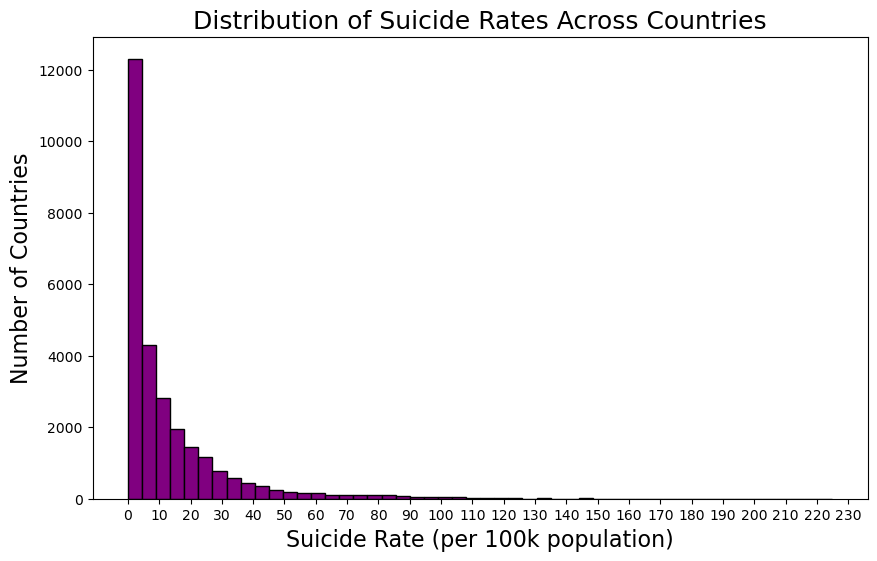

In [10]:
# Create a histogram for the suicide rate distribution
plt.figure(figsize=(10, 6))
plt.hist(suicide_df['suicides/100k pop'].dropna(), bins=50, color='purple', edgecolor='black')

# Add labels and title
plt.title('Distribution of Suicide Rates Across Countries', fontsize=18)
plt.xlabel('Suicide Rate (per 100k population)', fontsize=16)
plt.ylabel('Number of Countries', fontsize=16)

# Adjust x-axis ticks manually
tick_positions = range(0, int(suicide_df['suicides/100k pop'].max()) + 10, 10)  # Adjusted for better coverage
plt.xticks(tick_positions)

# Show the plot
plt.show()

#Comments:
#The histogram shows that most countries have low suicide rates, with the highest frequency occurring in the first bin
#indicating that suicide rates under 10 per 12000 are most common. As suicide rates increase, the number of countries 
#with higher rates decreases reflecting a left-skewed distribution.

# **Q3**. Using a pie chart , show the proportion of total suicides by gender for the most recent year available in the dataset. How do suicide rates differ between genders? Comment about your findings. (8 Points)

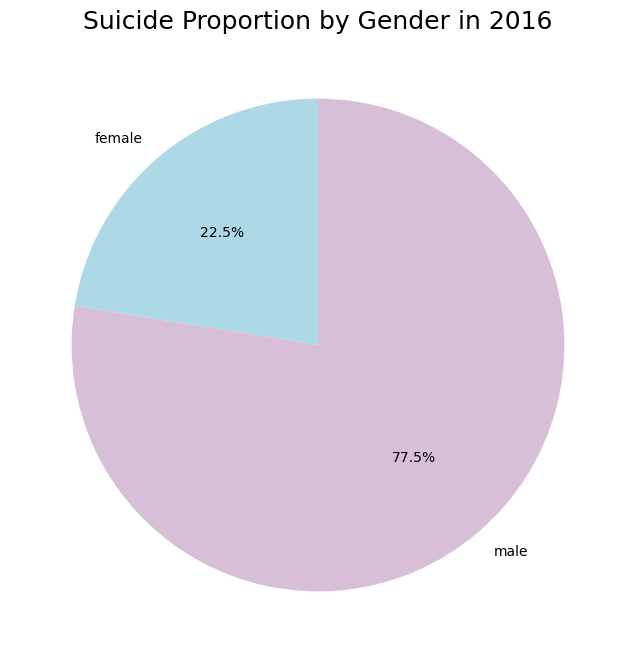

In [11]:
#Filter data for the most recent year
most_recent_year = suicide_df['year'].max()
recent_data = suicide_df[suicide_df['year'] == most_recent_year]

#Group by gender and calculate the total suicides for each gender
gender_suicides = recent_data.groupby('sex')['suicides_no'].sum()

#Plot a pie chart
plt.figure(figsize=(8, 8))
plt.pie(gender_suicides, labels=gender_suicides.index, autopct='%1.1f%%', colors=['lightblue', 'thistle'], startangle=90)

plt.title(f'Suicide Proportion by Gender in {most_recent_year}', fontsize=18)
plt.show()

#Comments:
#The pie chart shows that in the most recent year, males accounted for 77.5% of suicides, while females made up 22.5%. 
#This highlights a significant gender disparity, with males having a much higher suicide rate than females.

# **Q4**. Create a scatter plot showing the relationship between GDP per capita and suicide rate. Is there a correlation between a country's wealth (GDP per capita) and its suicide rates? Comment on any correlations or patterns you observe.(8 Points)

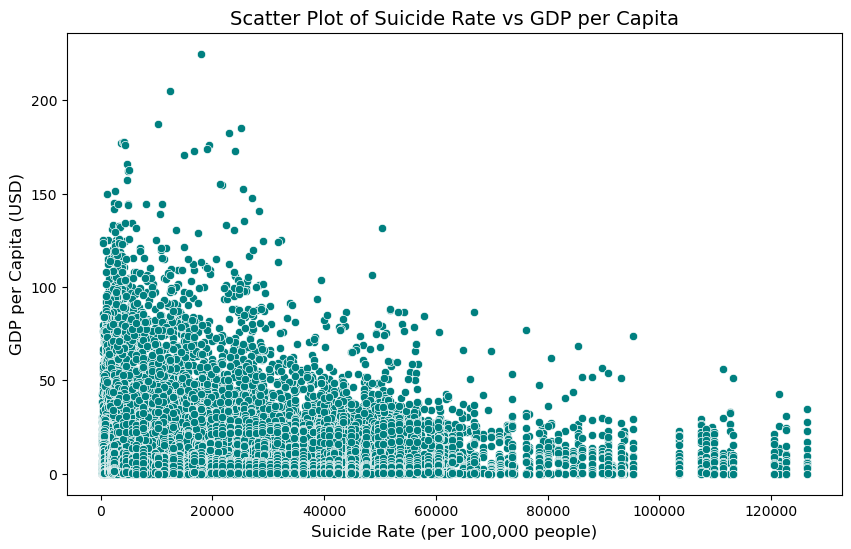

In [12]:
#Clean column names by stripping leading/trailing spaces
suicide_df.columns = suicide_df.columns.str.strip()

#Convert relevant columns to numeric, coercing any non-numeric values to NaN
suicide_df['gdp_per_capita ($)'] = pd.to_numeric(suicide_df['gdp_per_capita ($)'], errors='coerce')
suicide_df['suicides/100k pop'] = pd.to_numeric(suicide_df['suicides/100k pop'], errors='coerce')

#Drop rows with missing values in relevant columns
suicide_df = suicide_df.dropna(subset=['gdp_per_capita ($)', 'suicides/100k pop'])

#Scatter plot of GDP per Capita vs Suicide Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(data=suicide_df, x='gdp_per_capita ($)', y='suicides/100k pop', color='teal')

# Add labels and title
plt.title('Scatter Plot of Suicide Rate vs GDP per Capita', fontsize=14)
plt.xlabel('Suicide Rate (per 100,000 people)', fontsize=12)
plt.ylabel('GDP per Capita (USD)', fontsize=12)

plt.show()

#Comments:
#It is difficult to make a proper analysis due to the large amount of data (around 27k) in the scatter plot. 
#However, I didn't observe any straight line or curve in the resulting image. 
#I didn't observe any correlation between GDP per capita and suicide rates.

# **Q5.** Using  a bar chart, illustrating the top 10 countries with the highest suicide rates. Comment about the findings from this graph. (8 Points)

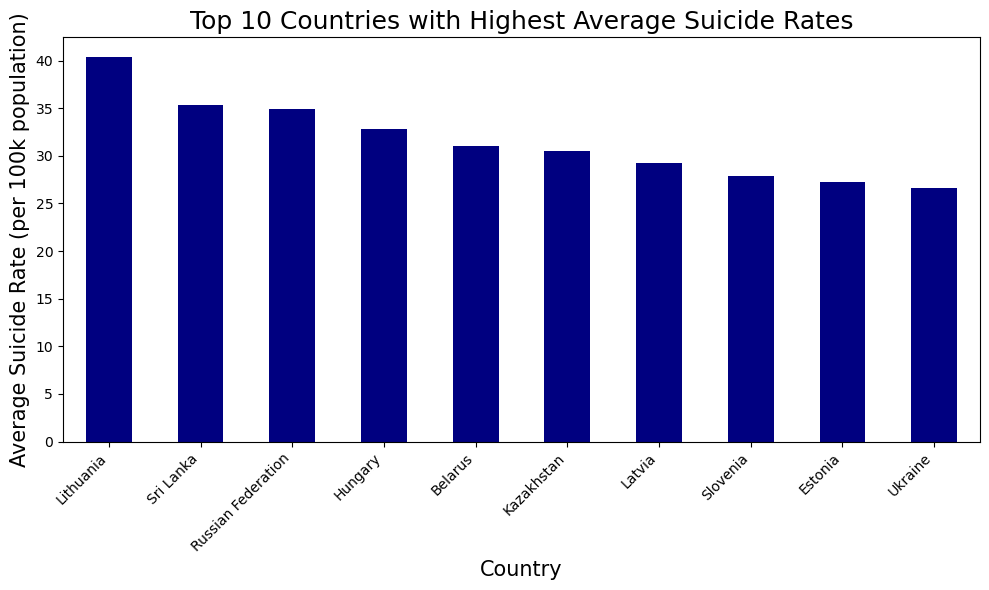

In [13]:
#Group by country and calculate the average suicide rate
average_suicide_rate = suicide_df.groupby('country')['suicides/100k pop'].mean()

#Sort the countries by suicide rate in descending order
sorted_suicide_rate = average_suicide_rate.sort_values(ascending=False)

#Get the top 10 countries with the highest suicide rates
top_10_countries = sorted_suicide_rate.head(10)

#Plot the bar chart
plt.figure(figsize=(10, 6))
top_10_countries.plot(kind='bar', color='navy')

#Customize the chart
plt.title('Top 10 Countries with Highest Average Suicide Rates', fontsize=18)
plt.xlabel('Country', fontsize=15)
plt.ylabel('Average Suicide Rate (per 100k population)', fontsize=15)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

#Comments:
#The chart reveals that Lithuania, Sri Lanka, and Russia have the highest suicide rates, 
#with several Eastern European and post-Soviet countries also appearing in the top 10, indicating a potential 
#correlation between regional factors such as socio-economic challenges, mental health resources, and societal pressures.

# SUBMIT FORMAT

* **<-zip>**
  - **studentID_name_surname_hw2.ipynb**


# PLAGIARISM

All work on assignments must be done individually. You are encouraged to discuss the given assignments with your classmates, but these discussions should be carried out in an abstract way. That is, discussions related to a particular solution to a specific probem (either in actual code or in pseudocode) will not be tolerated. In short, turning in someone else’s work (including work available on the internet), in whole or in part, as your own will be considered as a violation of academic integrity. Please note that the former conditions also hold for the material attained using AI tools, including ChatGPT, GitHub Copilot, etc.